# KNN_Classifier

## From Zero to One

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

### 数据读取

In [8]:
# 读取数据
m_x = np.loadtxt(
    fname=os.path.join("mnist_x"),
    delimiter=" "
)
m_y = np.loadtxt(
    fname=os.path.join("mnist_y"),
    delimiter=" "  
)

print(
    type(m_x), type(m_y),
    m_x.shape,
    m_y.shape
)

<class 'numpy.ndarray'> <class 'numpy.ndarray'> (1000, 784) (1000,)


(28, 28)


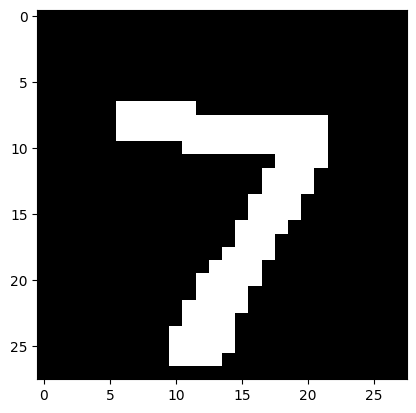

In [9]:
# 可视化数据
## 展示其中一张照片
data = np.reshape(
    m_x[0],
    shape=(28, 28)
)
print(
    # data,
    data.shape,
    sep="\n-----\n"
)
plt.figure()
plt.imshow(
    X=data,
    cmap="gray"
)


### 数据划分

In [10]:
# 划分数据集
ratio = 0.8
split = int(len(m_x[0]) * ratio)
print(
    split,
    len(m_x[0]) - split
)

627 157


In [11]:
# 打乱数据集
np.random.seed(0)
idx = np.random.permutation(len(m_x[0]))
# print(idx)
m_x = m_x[idx]
m_y = m_y[idx]
x_train, x_test = m_x[:split], m_x[split:]
y_train, y_test = m_y[:split], m_y[split:]
print(
    x_train.shape, x_test.shape,
    y_train.shape, y_test.shape,
)

(627, 784) (157, 784) (627,) (157,)


### 算法实现

In [7]:
# 定义距离函数
def distance(a, b):
    return np.sqrt(
        np.sum( (a-b)**2 )
    )

In [8]:
# 定义KNN算法
class KNN:
    def __init__(self, k, label_num):
        self.k = k                      # 近邻数量
        self.label_num = label_num      # 分类标签数量
    
    def fit(self, x_train, y_train):
        # 在对象存储训练数据
        self.x_train = x_train
        self.y_train = y_train
    
    def get_knn_indices(self, x):
        """
        获取与数据点x距离最近的K个近邻样本点
        """
        # 首先计算已知样本到目标样本点的距离
        dis = list(map(lambda a: distance(a,x), self.x_train))
        # 按照距离进行排序
        knn_indices = np.argsort(a=dis)
        # 取得最近的K个下标
        knn_indices = knn_indices[:self.k]
        return knn_indices

    def get_label(self, x):
        """
        观察K个近邻并获取其中类别最多的数量
        """
        knn_indices = self.get_knn_indices(x)
        # 类别计数
        label_statistic = np.zeros( shape=(self.label_num) )
        for index in knn_indices:
            label = int(self.y_train[index])
            label_statistic[label] += 1
        # 返回数量最多的类别
        return np.argmax(label_statistic)

    def predict(self, x_test):
        """
        对测试集数据进行预测
        """
        predicted_test_labels = np.zeros( shape=len(x_test), dtype=int )
        for i, x in enumerate(x_test):
            predicted_test_labels[i] = self.get_label(x)
        return predicted_test_labels

### 数据实验

In [9]:
for k in range(1,10):
    knn = KNN(k=k, label_num=10)
    knn.fit(x_train, y_train)
    predicted_labels = knn.predict(x_test)

    accuracy = np.mean(predicted_labels == y_test)
    print(
        f"近邻K的取值为 {k}, 预测准确率为 {accuracy*100: .1f}%"
    )

近邻K的取值为 1, 预测准确率为  87.9%
近邻K的取值为 2, 预测准确率为  88.5%
近邻K的取值为 3, 预测准确率为  89.8%
近邻K的取值为 4, 预测准确率为  87.9%
近邻K的取值为 5, 预测准确率为  88.5%
近邻K的取值为 6, 预测准确率为  86.6%
近邻K的取值为 7, 预测准确率为  88.5%
近邻K的取值为 8, 预测准确率为  88.5%
近邻K的取值为 9, 预测准确率为  88.5%


## Implementation with Scikit-Learn

### 数据读取

In [2]:
import numpy as np
import sklearn.neighbors as neighbors
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [ ]:
# 读取数据集
data = np.loadtxt(
    fname="gauss.csv",
    delimiter=","
)

x_train=data[:, :2]
y_train=data[:,2]
print(
    "数据集大小", data.shape,
    "训练集形状", x_train.shape,
    x_train,
    sep = "\n-----\n"
)

数据集大小
-----
(200, 3)
-----
200
-----
(200, 2)
-----
[[ 4.472   2.327 ]
 [ 2.9668  2.6252]
 [ 2.2212  3.1693]
 [ 1.4587  1.9728]
 [ 0.3717  3.0804]
 [ 2.2861  3.0933]
 [ 3.6493  0.912 ]
 [ 1.7738  4.1476]
 [ 2.8326  0.8275]
 [ 3.3727  0.0197]
 [ 3.1267  2.4699]
 [ 3.2341  0.5717]
 [ 2.9559  0.3611]
 [ 1.5953  2.5202]
 [ 3.1068  3.8364]
 [ 0.9145  3.5424]
 [ 2.2294  3.9528]
 [ 1.8832  1.2272]
 [ 4.057   1.125 ]
 [ 4.7596  0.2045]
 [-0.7081  2.1968]
 [ 2.5298  1.5368]
 [ 0.9669  1.7989]
 [ 4.0843 -0.1267]
 [ 2.9657  2.6145]
 [ 2.6197  0.0466]
 [ 0.4665  0.8661]
 [ 0.0373  3.6561]
 [ 0.2293  2.0309]
 [ 0.5631  2.5447]
 [ 0.595   4.1608]
 [-0.5676  2.1974]
 [ 1.1846  2.8574]
 [ 2.1784  2.3691]
 [ 4.1787  0.4801]
 [ 1.1091  4.6122]
 [ 4.0988 -0.0493]
 [ 0.7573  4.0883]
 [ 0.3364  3.181 ]
 [ 1.2327  2.4239]
 [ 4.2378  0.6607]
 [ 2.1532  3.3307]
 [ 3.9836  1.6695]
 [ 1.376   1.3515]
 [ 1.7649  1.1644]
 [ 3.8238  1.6773]
 [ 3.48    0.5409]
 [-0.2677  2.3574]
 [ 2.7829  0.668 ]
 [ 3.1366  1.3509

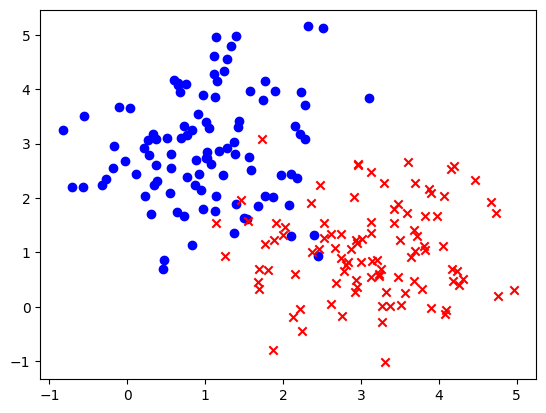

In [12]:
# 数据可视化
plt.figure()
plt.scatter( x_train[y_train==0, 0], x_train[y_train==0, 1], color="blue", marker="o")
plt.scatter( x_train[y_train==1, 0], x_train[y_train==1, 1], color="red", marker="x")

### 数据划分

In [13]:
# 将现有的所有点作为训练集，将一定网格内的均匀采样点作为测试集
## 设置步长
step = 0.02
## 设置边界
x_min, x_max = np.min(x_train[:,0])-1, np.max(x_train[:,0])+1
y_min, y_max = np.min(x_train[:,1])-1, np.max(x_train[:,1])+1
## 构造网格
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, step),
    np.arange(y_min, y_max, step),
)
grid_data = np.concatenate(
    [xx.reshape(-1,1), yy.reshape(-1,1)],
    axis=1
)

### 模型训练

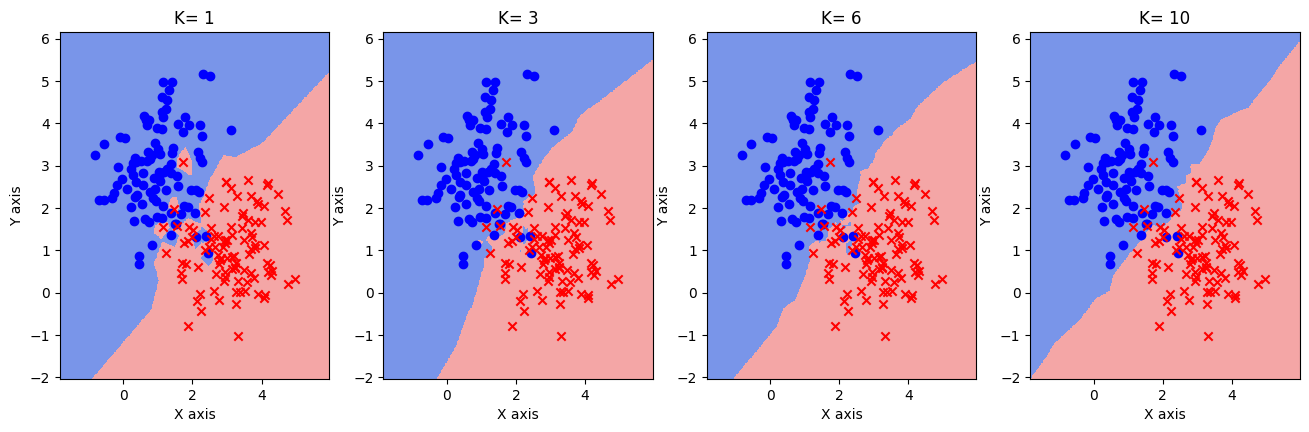

In [15]:
fig = plt.figure(figsize=(16,4.5))
# 设定近邻K值
ks = [1, 3, 6, 10]
cmap_light = colors.ListedColormap(["royalblue", "lightcoral"])

for i, k in enumerate(ks):
    # 定义KNN分类器
    knn = neighbors.KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    z = knn.predict(grid_data)

    # 画出分类结果
    ax = fig.add_subplot(1, 4, i+1)
    ax.pcolormesh(xx, yy, z.reshape(xx.shape), cmap=cmap_light, alpha=0.7)
    ax.scatter( x_train[y_train==0, 0], x_train[y_train==0, 1], color="blue", marker="o")
    ax.scatter( x_train[y_train==1, 0], x_train[y_train==1, 1], color="red", marker="x")

    ax.set_xlabel("X axis")
    ax.set_ylabel("Y axis")
    ax.set_title(f"K= {k}")

plt.show()